In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [42]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


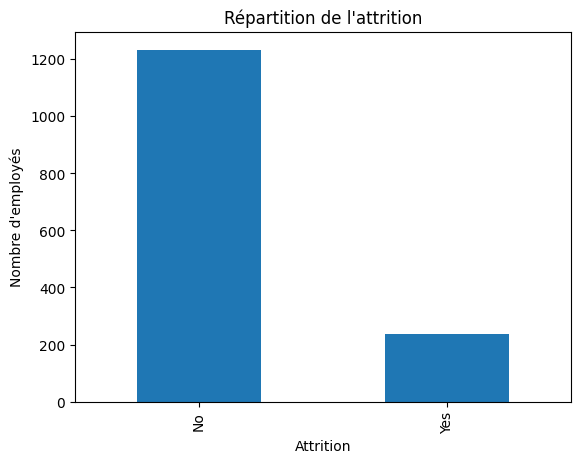

In [43]:
df['Attrition'].value_counts()
df['Attrition'].value_counts(normalize=True) * 100
df['Attrition'].value_counts().plot(kind='bar')
plt.title("Répartition de l'attrition")
plt.xlabel("Attrition")
plt.ylabel("Nombre d'employés")
plt.show()

In [44]:
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dept_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


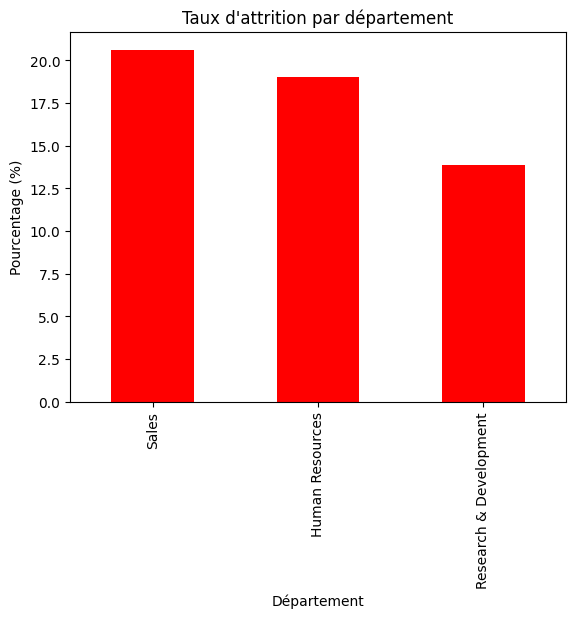

In [45]:
dept_attrition['Yes'].sort_values(ascending=False).plot(kind='bar', color='red')
plt.title("Taux d'attrition par département")
plt.xlabel("Département")
plt.ylabel("Pourcentage (%)")
plt.show()

In [46]:
job_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
job_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


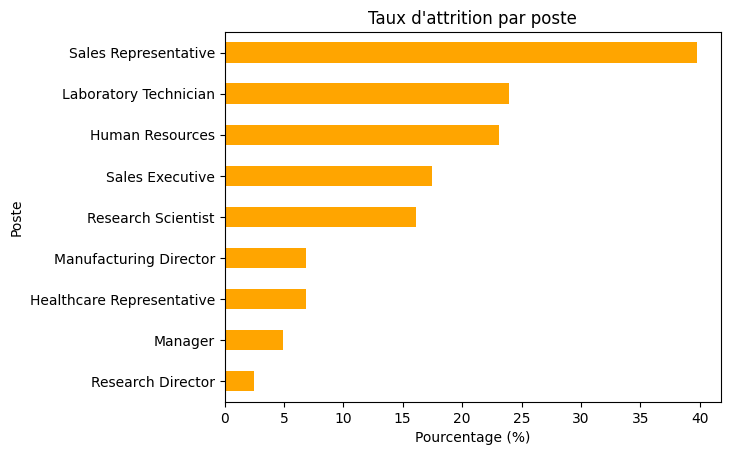

In [47]:
job_attrition['Yes'].sort_values().plot(kind='barh', color='orange')
plt.title("Taux d'attrition par poste")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Poste")
plt.show()

In [48]:
df.groupby('Attrition')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


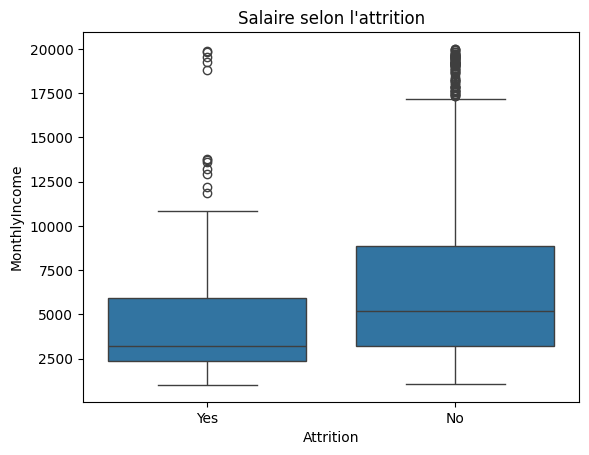

In [49]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title("Salaire selon l'attrition")
plt.show()

In [50]:
df.groupby('Attrition')['YearsAtCompany'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


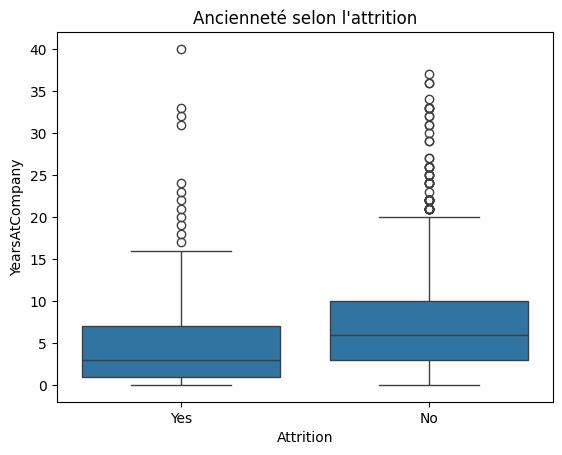

In [51]:
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')
plt.title("Ancienneté selon l'attrition")
plt.show()

In [52]:
from scipy.stats import chi2_contingency

contingency_dept = pd.crosstab(df['Department'], df['Attrition'])
chi2, p, dof, expected = chi2_contingency(contingency_dept)

print("p-value :", p)

p-value : 0.004525606574479633


In [53]:
if p < 0.05:
    print("Relation significative entre département et attrition")
else:
    print("Pas de relation significative")

Relation significative entre département et attrition


In [54]:
contingency_job = pd.crosstab(df['JobRole'], df['Attrition'])
chi2, p, dof, expected = chi2_contingency(contingency_job)

print("p-value (poste) :", p)

p-value (poste) : 2.752481638050657e-15


In [55]:
if p < 0.05:
    print("Le poste influence l'attrition")
else:
    print("Le poste n'influence pas l'attrition")

Le poste influence l'attrition


L’analyse des données a permis d’identifier les facteurs influençant l’attrition des employés.
Les résultats montrent que le taux de départ varie selon le département et le poste occupé.
Le test du Khi-deux confirme l’existence d’une relation statistiquement significative entre ces variables et l’attrition.
De plus, le salaire et l’ancienneté semblent également jouer un rôle dans la décision de quitter l’entreprise.
Ainsi, l’attrition ne dépend pas d’un seul facteur mais d’un ensemble de variables organisationnelles et individuelles.


L’analyse montre que le taux d’attrition dépend à la fois du département et du poste occupé.  
Les résultats descriptifs et le test du Khi-deux confirment l’existence d’une relation significative entre ces variables et le départ des employés.

## Recommandations RH

- Mettre en place des actions ciblées dans les départements à fort taux d’attrition
- Améliorer les conditions de travail pour les postes les plus touchés
- Revoir la politique salariale pour les profils à risque
- Renforcer l’intégration et le suivi des nouveaux employés
- Mettre en place des programmes de fidélisation (bonus, évolution interne)
- Réaliser des enquêtes internes pour comprendre les raisons des départs

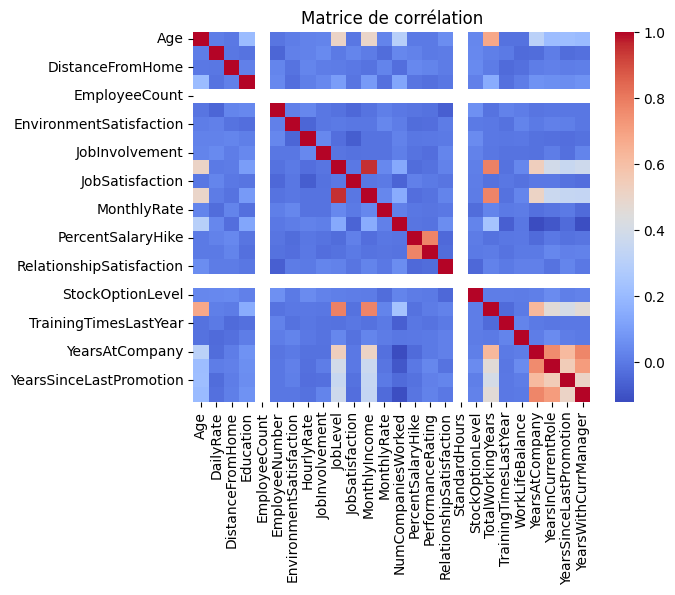

In [56]:
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()